# Lab 08- modelowanie danych

In [3]:
import pandas as pd

data = pd.read_csv("./dataset/deflection.csv", sep=";")

In [4]:
from statsmodels.formula.api import ols
model = ols('Deflection ~ Load', data=data)
res = model.fit()
res.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Deflection   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.310e+06
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           1.77e-95
Time:                        17:36:47   Log-Likelihood:                 189.57
No. Observations:                  40   AIC:                            -375.1
Df Residuals:                      38   BIC:                            -371.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0061      0.001      8.623      0.000       0.005       0.008
Load        7.221e-07   3.97e-10   1819.289      0.000    7.21e-07    7.23e-07
==============================================================================
Omnibus:                        5.525   Durbin-Watson:                   0.146
Prob(Omnibus):                  0.063   Jarque-Bera (JB):                4.146
Skew:                          -0.657   Prob(JB):                        0.126
Kurtosis:                       2.126   Cond. No.                     3.73e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.73e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Współczynnik determinacji określa dopasowanie modelu

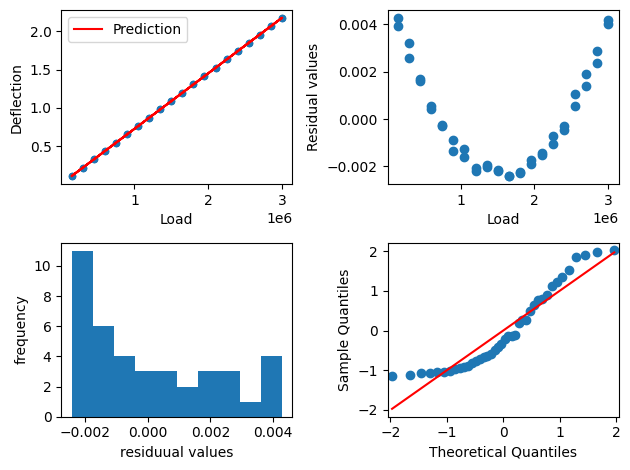

In [6]:
import statsmodels.graphics.gofplots as sm
import matplotlib.pyplot as plt
from scipy import stats

fig, axs = plt.subplots(2,2, squeeze=False)
data['Prediction'] = res.predict(data)
plt.tight_layout()

ax = data.plot.scatter(x='Load',y='Deflection', ax=axs[0,0])
data.plot(x='Load',y='Prediction', ax=axs[0,0], color='red')
# plt.subplot(2,2,2)
residuals = res.predict(data)-data['Deflection']
axs[0,1].scatter(data['Load'], (residuals))
axs[0,1].set_xlabel('Load')
axs[0,1].set_ylabel('Residual values')

axs[1,0].hist(residuals)
axs[1,0].set_ylabel('frequency')
axs[1,0].set_xlabel('residuual values')
plt.subplot(2,2,4)
sm.qqplot(residuals, stats.t, distargs=(4,), loc=3, scale=10, fit=True, ax=axs[1,1], line='s')
plt.tight_layout()

In [8]:
data['Load2'] = data['Load']**2
model = ols('Deflection ~ Load + Load2', data=data)
res = model.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Deflection   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.853e+08
Date:                Wed, 03 Dec 2025   Prob (F-statistic):          3.06e-130
Time:                        17:42:35   Log-Likelihood:                 284.47
No. Observations:                  40   AIC:                            -562.9
Df Residuals:                      37   BIC:                            -557.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0007      0.000      6.240      0.000       0.000       0.001
Load        7.321e-07   1.58e-10   4638.647      0.000    7.32e-07    7.32e-07
Load2      -3.161e-15   4.87e-17    -64.950      0.000   -3.26e-15   -3.06e-15
==============================================================================
Omnibus:                        0.133   Durbin-Watson:                   1.638
Prob(Omnibus):                  0.936   Jarque-Bera (JB):                0.190
Skew:                          -0.122   Prob(JB):                        0.909
Kurtosis:                       2.766   Cond. No.                     1.42e+13
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.42e+13. This might indicate that there are
strong multicollinearity or other numerical problems.
"""